In [3]:
!pip install --upgrade summa
!pip install --upgrade nltk
!pip install beautifulsoup4 lxml tqdm

  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'summa' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'summa'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for summa: filename=summa-1.2.0-py3-none-any.whl size=54441 sha256=88a9af48c2031615ed4f6b56df0d4dca088945f235810d4f7b4321d713688644
  Stored in directory: /home/jovyan/.cache/pip/wheels/70/26/84/58df5a55ebde6fd802666b6ac0b86909ecd018a2702b89d13c
Successfully built summa
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 9.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.2/801.2 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [nlt

In [4]:
from importlib.metadata import version
import nltk
import torch
import summa
import pandas as pd

print("nltk:", nltk.__version__)
print("torch:", torch.__version__)
print("pandas:", pd.__version__)
print("summa:", version('summa'))

nltk: 3.9.4
torch: 2.7.1+cu118
pandas: 2.3.0
summa: 1.2.0


In [5]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

텍스트 요약 실습에 필요한 패키지를 설치하고 버전을 확인한다.

In [6]:
import urllib.request
import pandas as pd

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv",
    filename="news_summary_more.csv"
)

data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')
data.head()

,headlines,text
0,upGrad learner switches to career in ML & Al w...,"Saurav Kant, an alumnus of upGrad and IIIT-B's..."
1,Delhi techie wins free food from Swiggy for on...,Kunal Shah's credit card bill payment platform...
2,New Zealand end Rohit Sharma-led India's 12-ma...,New Zealand defeated India by 8 wickets in the...
3,Aegon life iTerm insurance plan helps customer...,"With Aegon Life iTerm Insurance plan, customer..."
4,"Have known Hirani for yrs, what if MeToo claim...",Speaking about the sexual harassment allegatio...


In [7]:
print("전체 샘플 수:", len(data))
print(data.columns)

전체 샘플 수: 98401
Index(['headlines', 'text'], dtype='object')


뉴스 본문 text와 정답 요약문 headlines가 들어 있는 데이터를 불러온다.

data.info()
data.sample(5)

In [8]:
print(data.isnull().sum())

headlines    0
text         0
dtype: int64


In [9]:
print("text 유니크 개수:", data['text'].nunique())
print("headlines 유니크 개수:", data['headlines'].nunique())

text 유니크 개수: 98360
headlines 유니크 개수: 98280


모델에 넣기 전에 데이터가 어떤 구조인지 확인한다.

In [10]:
data.drop_duplicates(subset=['text'], inplace=True)
data.dropna(axis=0, inplace=True)

print("정리 후 샘플 수:", len(data))
print(data.isnull().sum())

정리 후 샘플 수: 98360
headlines    0
text         0
dtype: int64


같은 기사나 비어 있는 기사를 제거해서 학습 데이터를 깨끗하게 만든다.

In [11]:
data.drop_duplicates(subset=['text'], inplace=True)
data.dropna(axis=0, inplace=True)

print("정리 후 샘플 수:", len(data))
print(data.isnull().sum())

정리 후 샘플 수: 98360
headlines    0
text         0
dtype: int64


같은 기사나 비어 있는 기사를 제거해서 학습 데이터를 깨끗하게 만든다.

In [12]:
import re
import html
import numpy as np
from nltk.corpus import stopwords
from tqdm import tqdm

contractions = {
    "ain't": "is not",
    "aren't": "are not",
    "can't": "cannot",
    "couldn't": "could not",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hasn't": "has not",
    "haven't": "have not",
    "he's": "he is",
    "i'm": "i am",
    "it's": "it is",
    "let's": "let us",
    "shouldn't": "should not",
    "that's": "that is",
    "there's": "there is",
    "they're": "they are",
    "wasn't": "was not",
    "weren't": "were not",
    "what's": "what is",
    "won't": "will not",
    "wouldn't": "would not",
    "you're": "you are"
}

stop_words = set(stopwords.words("english"))

HTML_CLEANER = re.compile("<[^>]*>")
PAREN_CLEANER = re.compile(r"\([^)]*\)")
QUOTE_CLEANER = re.compile('"')
POSSESSIVE_CLEANER = re.compile(r"'s\b")
NON_ALPHA_CLEANER = re.compile("[^a-zA-Z]")
M_CLEANER = re.compile("[m]{2,}")

def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = sentence.lower()
    sentence = HTML_CLEANER.sub("", sentence)
    sentence = html.unescape(sentence)
    sentence = PAREN_CLEANER.sub("", sentence)
    sentence = QUOTE_CLEANER.sub("", sentence)

    sentence = " ".join(
        contractions[word] if word in contractions else word
        for word in sentence.split()
    )

    sentence = POSSESSIVE_CLEANER.sub("", sentence)
    sentence = NON_ALPHA_CLEANER.sub(" ", sentence)
    sentence = M_CLEANER.sub("mm", sentence)

    words = sentence.split()

    if remove_stopwords:
        result = " ".join(
            word for word in words
            if word not in stop_words and len(word) > 1
        )
    else:
        result = " ".join(
            word for word in words
            if len(word) > 1
        )

    return result

In [13]:
temp_text = "India's economy wasn't slowing down <br /> according to officials."
temp_headline = "India's economy wasn't slowing down"

print("text:", preprocess_sentence(temp_text, remove_stopwords=True))
print("headline:", preprocess_sentence(temp_headline, remove_stopwords=False))

text: india economy slowing according officials
headline: india economy was not slowing down


모델이 학습하기 쉽도록 문장을 정제하되, 요약문은 자연스러움을 유지한다.

In [14]:
clean_text = [
    preprocess_sentence(sentence, remove_stopwords=True)
    for sentence in tqdm(data['text'])
]

clean_headlines = [
    preprocess_sentence(sentence, remove_stopwords=False)
    for sentence in tqdm(data['headlines'])
]

print(clean_text[:3])
print(clean_headlines[:3])

100%|██████████| 98360/98360 [00:01<00:00, 58716.56it/s]

['saurav kant alumnus upgrad iiit pg program machine learning artificial intelligence sr systems engineer infosys almost years work experience program upgrad degree career support helped transition data scientist tech mahindra salary hike upgrad online power learning powered lakh careers', 'kunal shah credit card bill payment platform cred gave users chance win free food swiggy one year pranav kaushik delhi techie bagged reward spending cred coins users get one cred coin per rupee bill paid used avail rewards brands like ixigo bookmyshow ubereats cult fit', 'new zealand defeated india wickets fourth odi hamilton thursday win first match five match odi series india lost international match rohit sharma captaincy consecutive victories dating back march match witnessed india getting seventh lowest total odi cricket history']
['upgrad learner switches to career in ml al with salary hike', 'delhi techie wins free food from swiggy for one year on cred', 'new zealand end rohit sharma led indi

In [15]:
data['text'] = clean_text
data['headlines'] = clean_headlines

data.replace('', np.nan, inplace=True)
print(data.isnull().sum())

data.dropna(axis=0, inplace=True)
print("빈 샘플 제거 후 샘플 수:", len(data))

headlines    0
text         0
dtype: int64
빈 샘플 제거 후 샘플 수: 98360


전체 뉴스 데이터에 전처리를 적용하고 빈 샘플을 제거한다.

Text 최소 길이: 1
Text 최대 길이: 60
Text 평균 길이: 35.095404636030906
Summary 최소 길이: 1
Summary 최대 길이: 16
Summary 평균 길이: 9.29690931272875


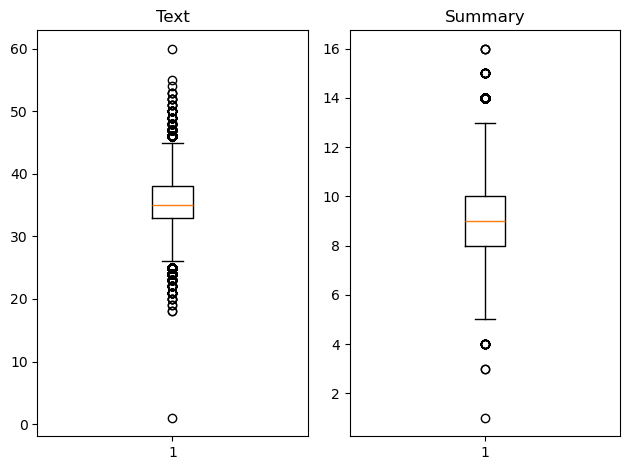

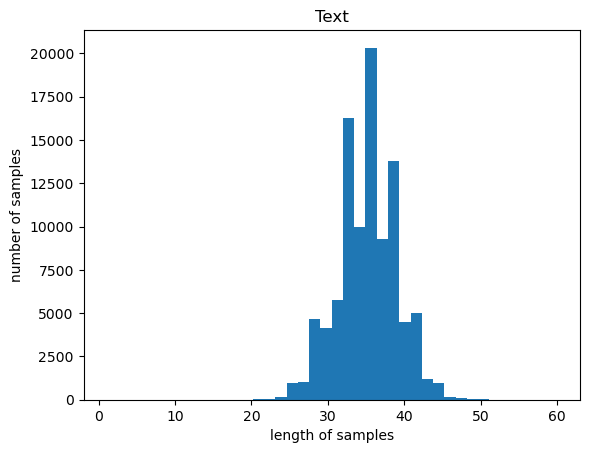

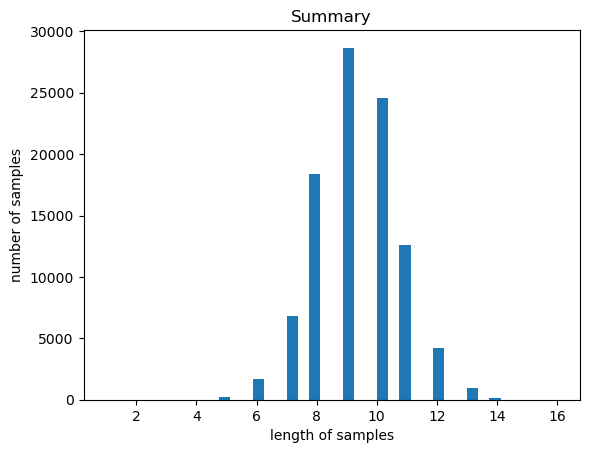

In [16]:
import matplotlib.pyplot as plt

text_len = [len(s.split()) for s in data['text']]
summary_len = [len(s.split()) for s in data['headlines']]

print("Text 최소 길이:", np.min(text_len))
print("Text 최대 길이:", np.max(text_len))
print("Text 평균 길이:", np.mean(text_len))

print("Summary 최소 길이:", np.min(summary_len))
print("Summary 최대 길이:", np.max(summary_len))
print("Summary 평균 길이:", np.mean(summary_len))

plt.subplot(1, 2, 1)
plt.boxplot(text_len)
plt.title("Text")

plt.subplot(1, 2, 2)
plt.boxplot(summary_len)
plt.title("Summary")

plt.tight_layout()
plt.show()

plt.title("Text")
plt.hist(text_len, bins=40)
plt.xlabel("length of samples")
plt.ylabel("number of samples")
plt.show()

plt.title("Summary")
plt.hist(summary_len, bins=40)
plt.xlabel("length of samples")
plt.ylabel("number of samples")
plt.show()

Text는 기사 본문이므로 Summary보다 길다.
Summary는 headlines라서 상대적으로 짧다.
너무 긴 문장은 학습 시간을 늘리고 패딩을 많이 만들 수 있으므로 최대 길이를 정해야 한다.

In [17]:
text_max_len = 60
summary_max_len = 15

문장 길이 분포를 보고 모델에 넣을 최대 길이를 정한다.

In [18]:
text_max_len = 60
summary_max_len = 15

def below_threshold_len(max_len, data_list):
    count = 0
    for sentence in data_list:
        if len(sentence.split()) <= max_len:
            count += 1

    print(
        f"전체 샘플 중 길이가 {max_len} 이하인 샘플 비율: "
        f"{count / len(data_list) * 100:.2f}%"
    )

below_threshold_len(text_max_len, data['text'])
below_threshold_len(summary_max_len, data['headlines'])

전체 샘플 중 길이가 60 이하인 샘플 비율: 100.00%
전체 샘플 중 길이가 15 이하인 샘플 비율: 100.00%


In [19]:
data = data[
    data['text'].apply(lambda x: len(x.split()) <= text_max_len)
]

data = data[
    data['headlines'].apply(lambda x: len(x.split()) <= summary_max_len)
]

print("길이 필터링 후 샘플 수:", len(data))

길이 필터링 후 샘플 수: 98357


너무 긴 문장을 제외해서 학습 가능한 크기로 데이터를 정리한다.

In [20]:
data['decoder_input'] = data['headlines'].apply(lambda x: 'sostoken ' + x)
data['decoder_target'] = data['headlines'].apply(lambda x: x + ' eostoken')

data[['headlines', 'decoder_input', 'decoder_target']].head()

,headlines,decoder_input,decoder_target
0,upgrad learner switches to career in ml al wit...,sostoken upgrad learner switches to career in ...,upgrad learner switches to career in ml al wit...
1,delhi techie wins free food from swiggy for on...,sostoken delhi techie wins free food from swig...,delhi techie wins free food from swiggy for on...
2,new zealand end rohit sharma led india match w...,sostoken new zealand end rohit sharma led indi...,new zealand end rohit sharma led india match w...
3,aegon life iterm insurance plan helps customer...,sostoken aegon life iterm insurance plan helps...,aegon life iterm insurance plan helps customer...
4,have known hirani for yrs what if metoo claims...,sostoken have known hirani for yrs what if met...,have known hirani for yrs what if metoo claims...


headlines:
india wins match

decoder_input:
sostoken india wins match

decoder_target:
india wins match eostoken

디코더가 문장을 시작하고 끝내는 법을 배우도록 특수 토큰을 붙인다.

import numpy as np

encoder_input = np.array(data['text'])
decoder_input = np.array(data['decoder_input'])
decoder_target = np.array(data['decoder_target'])

indices = np.arange(encoder_input.shape[0])
np.random.shuffle(indices)

encoder_input = encoder_input[indices]
decoder_input = decoder_input[indices]
decoder_target = decoder_target[indices]

n_of_val = int(len(encoder_input) * 0.2)

encoder_input_train = encoder_input[:-n_of_val]
decoder_input_train = decoder_input[:-n_of_val]
decoder_target_train = decoder_target[:-n_of_val]

encoder_input_test = encoder_input[-n_of_val:]
decoder_input_test = decoder_input[-n_of_val:]
decoder_target_test = decoder_target[-n_of_val:]

print("훈련 데이터 개수:", len(encoder_input_train))
print("테스트 데이터 개수:", len(encoder_input_test))

In [22]:
from collections import Counter

def tokenizer(text):
    return text.split()

def build_limited_vocab(texts, vocab_size):
    vocab = {"<PAD>": 0, "<UNK>": 1}
    word_counter = Counter()

    for text in texts:
        word_counter.update(tokenizer(text))

    for word, _ in word_counter.most_common(vocab_size - 2):
        vocab[word] = len(vocab)

    return vocab

자주 등장하는 단어를 중심으로 입력 단어장과 출력 단어장을 만든다.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

embedding_dim = 128
hidden_size = 256

class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell

In [ ]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

    def forward(self, x, hidden, cell):
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        return outputs, hidden, cell

In [ ]:
class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder, hidden_size, tar_vocab_size):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.attention = AttentionDot()
        self.concat = nn.Linear(hidden_size * 2, hidden_size)
        self.output_layer = nn.Linear(hidden_size, tar_vocab_size)

    def forward(self, encoder_input, decoder_input):
        encoder_outputs, hidden, cell = self.encoder(encoder_input)
        decoder_outputs, _, _ = self.decoder(decoder_input, hidden, cell)

        context, attn_weights = self.attention(decoder_outputs, encoder_outputs)

        concat_output = torch.cat([decoder_outputs, context], dim=-1)
        concat_output = torch.tanh(self.concat(concat_output))

        outputs = self.output_layer(concat_output)
        return outputs

In [ ]:
encoder = Encoder(len(src_vocab), embedding_dim, hidden_size)
decoder = Decoder(len(tar_vocab), embedding_dim, hidden_size)

model = Seq2SeqWithAttention(
    encoder,
    decoder,
    hidden_size,
    len(tar_vocab)
)

print(model)

In [ ]:
class AttentionDot(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, decoder_outputs, encoder_outputs):
        # decoder_outputs: [batch, summary_len, hidden_size]
        # encoder_outputs: [batch, text_len, hidden_size]

        scores = torch.bmm(
            decoder_outputs,
            encoder_outputs.transpose(1, 2)
        )

        attn_weights = F.softmax(scores, dim=-1)
        context = torch.bmm(attn_weights, encoder_outputs)

        return context, attn_weights

In [ ]:
class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder, hidden_size, tar_vocab_size):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.attention = AttentionDot()
        self.concat = nn.Linear(hidden_size * 2, hidden_size)
        self.output_layer = nn.Linear(hidden_size, tar_vocab_size)

    def forward(self, encoder_input, decoder_input):
        encoder_outputs, hidden, cell = self.encoder(encoder_input)
        decoder_outputs, _, _ = self.decoder(decoder_input, hidden, cell)

        context, attn_weights = self.attention(decoder_outputs, encoder_outputs)

        concat_output = torch.cat([decoder_outputs, context], dim=-1)
        concat_output = torch.tanh(self.concat(concat_output))

        outputs = self.output_layer(concat_output)
        return outputs

In [ ]:
encoder = Encoder(len(src_vocab), embedding_dim, hidden_size)
decoder = Decoder(len(tar_vocab), embedding_dim, hidden_size)

model = Seq2SeqWithAttention(
    encoder,
    decoder,
    hidden_size,
    len(tar_vocab)
)

print(model)

In [ ]:
print(encoder_input_train.shape)
print(decoder_input_train.shape)
print(decoder_target_train.shape)
print(encoder_input_test.shape)
print(decoder_input_test.shape)
print(decoder_target_test.shape)

In [ ]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model.to(device)

batch_size = 256
epochs = 50
learning_rate = 0.001
patience = 2

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

train_dataset = TensorDataset(
    encoder_input_train,
    decoder_input_train,
    decoder_target_train
)

test_dataset = TensorDataset(
    encoder_input_test,
    decoder_input_test,
    decoder_target_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("train batch 개수:", len(train_loader))
print("test batch 개수:", len(test_loader))

In [ ]:
print("batch_size:", batch_size)

In [ ]:
train_losses = []
val_losses = []

def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, patience):
    best_val_loss = float('inf')
    early_stop_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for enc_input, dec_input, target in train_loader:
            enc_input = enc_input.to(device).long()
            dec_input = dec_input.to(device).long()
            target = target.to(device).long()

            optimizer.zero_grad()

            output = model(enc_input, dec_input)

            output = output.reshape(-1, output.shape[-1])
            target = target.reshape(-1)

            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for enc_input, dec_input, target in test_loader:
                enc_input = enc_input.to(device).long()
                dec_input = dec_input.to(device).long()
                target = target.to(device).long()

                output = model(enc_input, dec_input)

                output = output.reshape(-1, output.shape[-1])
                target = target.reshape(-1)

                loss = criterion(output, target)
                val_loss += loss.item()

        val_loss /= len(test_loader)
        val_losses.append(val_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {avg_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            best_model_state = model.state_dict()
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch + 1}")
            if best_model_state is not None:
                model.load_state_dict(best_model_state)
            break

In [ ]:
train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    epochs,
    patience
)

In [ ]:
print("model" in globals())
print("train_loader" in globals())
print("criterion" in globals())
print("optimizer" in globals())
print("train_model" in globals())

In [26]:
import numpy as np

# 1. 현재 data 상태 확인
print(data.columns)
print(data.shape)

# 2. decoder_input / decoder_target이 없으면 다시 생성
if 'decoder_input' not in data.columns:
    data['decoder_input'] = data['headlines'].apply(lambda x: 'sostoken ' + x)

if 'decoder_target' not in data.columns:
    data['decoder_target'] = data['headlines'].apply(lambda x: x + ' eostoken')

# 3. Encoder / Decoder 입력 만들기
encoder_input = np.array(data['text'])
decoder_input = np.array(data['decoder_input'])
decoder_target = np.array(data['decoder_target'])

# 4. 데이터 섞기
indices = np.arange(encoder_input.shape[0])
np.random.shuffle(indices)

encoder_input = encoder_input[indices]
decoder_input = decoder_input[indices]
decoder_target = decoder_target[indices]

# 5. train / test 분리
n_of_val = int(len(encoder_input) * 0.2)

encoder_input_train = encoder_input[:-n_of_val]
decoder_input_train = decoder_input[:-n_of_val]
decoder_target_train = decoder_target[:-n_of_val]

encoder_input_test = encoder_input[-n_of_val:]
decoder_input_test = decoder_input[-n_of_val:]
decoder_target_test = decoder_target[-n_of_val:]

print("훈련 데이터 개수:", len(encoder_input_train))
print("테스트 데이터 개수:", len(encoder_input_test))
print("encoder_input_train 예시:", encoder_input_train[0])
print("decoder_input_train 예시:", decoder_input_train[0])
print("decoder_target_train 예시:", decoder_target_train[0])

Index(['headlines', 'text', 'decoder_input', 'decoder_target'], dtype='object')
(98357, 4)
훈련 데이터 개수: 78686
테스트 데이터 개수: 19671
encoder_input_train 예시: criticising deletion smoking scenes manmarziyaan actress taapsee pannu tweeted sure edit assure sikh ever smoke sikh organisation especially raised objection abhishek bachchan sikh character shown smoking removing turban surely make waheguru proud assures religion purest added taapsee
decoder_input_train 예시: sostoken am sure deleted scene will assure no sikh will ever smoke taapsee
decoder_target_train 예시: am sure deleted scene will assure no sikh will ever smoke taapsee eostoken


In [27]:
src_vocab_size = 10000
tar_vocab_size = 5000

src_vocab = build_limited_vocab(encoder_input_train, src_vocab_size)
tar_vocab = build_limited_vocab(
    list(decoder_input_train) + list(decoder_target_train),
    tar_vocab_size
)

print("src_vocab 크기:", len(src_vocab))
print("tar_vocab 크기:", len(tar_vocab))

src_vocab 크기: 10000
tar_vocab 크기: 5000


In [28]:
def tokenizer(text):
    return text.split()

def text_to_sequence(texts, vocab):
    sequences = []

    for text in texts:
        sequence = [
            vocab.get(word, vocab["<UNK>"])
            for word in tokenizer(text)
        ]
        sequences.append(sequence)

    return sequences


encoder_input_train_seq = text_to_sequence(encoder_input_train, src_vocab)
encoder_input_test_seq = text_to_sequence(encoder_input_test, src_vocab)

decoder_input_train_seq = text_to_sequence(decoder_input_train, tar_vocab)
decoder_target_train_seq = text_to_sequence(decoder_target_train, tar_vocab)

decoder_input_test_seq = text_to_sequence(decoder_input_test, tar_vocab)
decoder_target_test_seq = text_to_sequence(decoder_target_test, tar_vocab)

print("encoder_input_train_seq 예시:", encoder_input_train_seq[0][:20])
print("decoder_input_train_seq 예시:", decoder_input_train_seq[0])
print("decoder_target_train_seq 예시:", decoder_target_train_seq[0])

encoder_input_train_seq 예시: [2986, 1, 3288, 2987, 1, 80, 2828, 3891, 72, 1747, 1, 9480, 1980, 216, 4071, 1980, 696, 3227, 294, 6411]
decoder_input_train_seq 예시: [2, 146, 4037, 3691, 1675, 26, 1, 45, 1258, 26, 213, 3499, 1418]
decoder_target_train_seq 예시: [146, 4037, 3691, 1675, 26, 1, 45, 1258, 26, 213, 3499, 1418, 3]


단어로 된 문장을 모델이 이해할 수 있는 숫자 시퀀스로 바꾸는 단계

In [29]:
import torch
from torch.nn.utils.rnn import pad_sequence

text_max_len = 60
summary_max_len = 15

def convert_to_tensor(sequences):
    return [torch.tensor(seq, dtype=torch.long) for seq in sequences]

def pad_sequences_pytorch(sequences, maxlen, padding_value=0):
    sequences = convert_to_tensor(sequences)

    padded = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=padding_value
    )

    if padded.size(1) < maxlen:
        pad_size = maxlen - padded.size(1)
        padded = torch.cat(
            [
                padded,
                torch.zeros((padded.size(0), pad_size), dtype=torch.long)
            ],
            dim=1
        )

    return padded[:, :maxlen]


encoder_input_train = pad_sequences_pytorch(encoder_input_train_seq, text_max_len)
encoder_input_test = pad_sequences_pytorch(encoder_input_test_seq, text_max_len)

decoder_input_train = pad_sequences_pytorch(decoder_input_train_seq, summary_max_len)
decoder_target_train = pad_sequences_pytorch(decoder_target_train_seq, summary_max_len)

decoder_input_test = pad_sequences_pytorch(decoder_input_test_seq, summary_max_len)
decoder_target_test = pad_sequences_pytorch(decoder_target_test_seq, summary_max_len)

print(encoder_input_train.shape)
print(decoder_input_train.shape)
print(decoder_target_train.shape)
print(encoder_input_test.shape)
print(decoder_input_test.shape)
print(decoder_target_test.shape)

torch.Size([78686, 60])
torch.Size([78686, 15])
torch.Size([78686, 15])
torch.Size([19671, 60])
torch.Size([19671, 15])
torch.Size([19671, 15])


길이가 서로 다른 문장을 Text=60, Summary=15 길이로 맞추는 단계

In [30]:
import torch.nn as nn
import torch.nn.functional as F

embedding_dim = 128
hidden_size = 256


class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell


class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

    def forward(self, x, hidden, cell):
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        return outputs, hidden, cell


class AttentionDot(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, decoder_outputs, encoder_outputs):
        scores = torch.bmm(
            decoder_outputs,
            encoder_outputs.transpose(1, 2)
        )

        attn_weights = F.softmax(scores, dim=-1)
        context = torch.bmm(attn_weights, encoder_outputs)

        return context, attn_weights


class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder, hidden_size, tar_vocab_size):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.attention = AttentionDot()
        self.concat = nn.Linear(hidden_size * 2, hidden_size)
        self.output_layer = nn.Linear(hidden_size, tar_vocab_size)

    def forward(self, encoder_input, decoder_input):
        encoder_outputs, hidden, cell = self.encoder(encoder_input)
        decoder_outputs, _, _ = self.decoder(decoder_input, hidden, cell)

        context, attn_weights = self.attention(decoder_outputs, encoder_outputs)

        concat_output = torch.cat([decoder_outputs, context], dim=-1)
        concat_output = torch.tanh(self.concat(concat_output))

        outputs = self.output_layer(concat_output)
        return outputs

In [31]:
encoder = Encoder(len(src_vocab), embedding_dim, hidden_size)
decoder = Decoder(len(tar_vocab), embedding_dim, hidden_size)

model = Seq2SeqWithAttention(
    encoder,
    decoder,
    hidden_size,
    len(tar_vocab)
)

print(model)

Seq2SeqWithAttention(
  (encoder): Encoder(
    (embedding): Embedding(10000, 128, padding_idx=0)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(5000, 128, padding_idx=0)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (attention): AttentionDot()
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=5000, bias=True)
)


In [32]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model.to(device)

batch_size = 256
epochs = 50
learning_rate = 0.001
patience = 2

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

train_dataset = TensorDataset(
    encoder_input_train,
    decoder_input_train,
    decoder_target_train
)

test_dataset = TensorDataset(
    encoder_input_test,
    decoder_input_test,
    decoder_target_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("train batch 개수:", len(train_loader))
print("test batch 개수:", len(test_loader))

Using device: cuda
train batch 개수: 308
test batch 개수: 77


In [40]:
import copy

train_losses = []
val_losses = []

def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, patience):
    best_val_loss = float('inf')
    early_stop_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for enc_input, dec_input, target in train_loader:
            enc_input = enc_input.to(device).long()
            dec_input = dec_input.to(device).long()
            target = target.to(device).long()

            optimizer.zero_grad()

            output = model(enc_input, dec_input)

            output = output.reshape(-1, output.shape[-1])
            target = target.reshape(-1)

            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for enc_input, dec_input, target in test_loader:
                enc_input = enc_input.to(device).long()
                dec_input = dec_input.to(device).long()
                target = target.to(device).long()

                output = model(enc_input, dec_input)

                output = output.reshape(-1, output.shape[-1])
                target = target.reshape(-1)

                loss = criterion(output, target)
                val_loss += loss.item()

        val_loss /= len(test_loader)
        val_losses.append(val_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {avg_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch + 1}")
            if best_model_state is not None:
                model.load_state_dict(best_model_state)
            break

In [41]:
train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    epochs,
    patience
)

Epoch 1/3 | Train Loss: 2.7224 | Val Loss: 3.8127
Epoch 2/3 | Train Loss: 2.6917 | Val Loss: 3.8261
Early stopping triggered at epoch 2


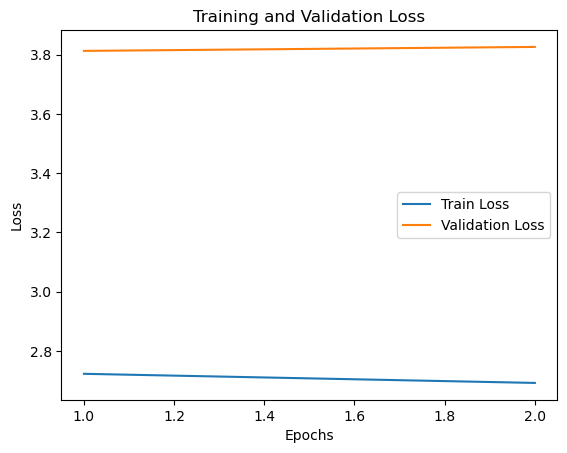

In [42]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.show()

Train loss는 감소하였으나 validation loss는 소폭 증가하였다. 이에 따라 Early Stopping이 작동하였고, 과적합을 방지하기 위해 학습이 조기 종료되었다.

In [43]:
src_index_to_word = {idx: word for word, idx in src_vocab.items()}
tar_word_to_index = tar_vocab
tar_index_to_word = {idx: word for word, idx in tar_vocab.items()}

def seq2text(input_seq):
    temp = ''

    for i in input_seq:
        key = int(i.item()) if hasattr(i, 'item') else int(i)

        if key != 0:
            temp += src_index_to_word.get(key, "<UNK>") + ' '

    return temp.strip()


def seq2summary(input_seq):
    temp = ''

    for i in input_seq:
        key = int(i.item()) if hasattr(i, 'item') else int(i)

        if key == 0:
            continue
        if key == tar_word_to_index.get('sostoken'):
            continue
        if key == tar_word_to_index.get('eostoken'):
            continue

        temp += tar_index_to_word.get(key, "<UNK>") + ' '

    return temp.strip()

print("복원 함수 준비 완료")

복원 함수 준비 완료


In [44]:
def greedy_decode(input_seq):
    model.eval()

    input_seq = input_seq.to(device).long()

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(input_seq)

    target_seq = torch.tensor(
        [[tar_word_to_index['sostoken']]],
        dtype=torch.long,
        device=device
    )

    decoded_sentence = []

    for _ in range(summary_max_len):
        with torch.no_grad():
            decoder_outputs, hidden, cell = model.decoder(target_seq, hidden, cell)

            context, _ = model.attention(decoder_outputs, encoder_outputs)

            concat_output = torch.cat([decoder_outputs, context], dim=-1)
            concat_output = torch.tanh(model.concat(concat_output))

            output = model.output_layer(concat_output)

            sampled_token_index = torch.argmax(output[0, -1, :]).item()
            sampled_token = tar_index_to_word.get(sampled_token_index, "<UNK>")

        if sampled_token == 'eostoken':
            break

        decoded_sentence.append(sampled_token)

        target_seq = torch.tensor(
            [[sampled_token_index]],
            dtype=torch.long,
            device=device
        )

    return ' '.join(decoded_sentence)

print("greedy_decode 준비 완료")

greedy_decode 준비 완료


In [45]:
for i in range(10):
    print("원문 :", seq2text(encoder_input_test[i]))
    print("실제 요약 :", seq2summary(decoder_input_test[i]))

    input_seq = encoder_input_test[i].unsqueeze(0)
    print("예측 요약 :", greedy_decode(input_seq))

    print("-" * 80)

원문 : karan johar said directorial <UNK> dil hai <UNK> film completely satisfied one film would change anything added speaking films johar said think <UNK> <UNK> scenes kuch kuch hota hai kabhi khushi <UNK> <UNK> probably long
실제 요약 : <UNK> dil hai <UNK> my only film am <UNK> with johar
예측 요약 : <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> karan johar
--------------------------------------------------------------------------------
원문 : chennai woman committed suicide husband justified affair another woman saying could stop supreme court recently ruled adultery crime anymore wife earlier threatened call police came know affair ill couple married two years
실제 요약 : wife ends life after man <UNK> affair saying <UNK> is legal
예측 요약 : <UNK> <UNK> wife wife husband to be <UNK> on divorce
--------------------------------------------------------------------------------
원문 : president ram nath kovind along wife son daughter offered prayers temple lord <UNK> hill shrine <UNK> andhra pradesh saturday o

예측 요약에서는 반복 표현이나 일반적인 단어 위주의 출력이 일부 나타났다. 이는 학습 epoch가 적고, 희귀 단어가 <UNK>로 처리되었으며, greedy decoding을 사용했기 때문으로 해석된다.

In [46]:
!pip install summa

from summa.summarizer import summarize

In [47]:
raw_data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')
raw_data.drop_duplicates(subset=['text'], inplace=True)
raw_data.dropna(axis=0, inplace=True)

print(raw_data.head())

                                           headlines  \
0  upGrad learner switches to career in ML & Al w...   
1  Delhi techie wins free food from Swiggy for on...   
2  New Zealand end Rohit Sharma-led India's 12-ma...   
3  Aegon life iTerm insurance plan helps customer...   
4  Have known Hirani for yrs, what if MeToo claim...   

                                                text  
0  Saurav Kant, an alumnus of upGrad and IIIT-B's...  
1  Kunal Shah's credit card bill payment platform...  
2  New Zealand defeated India by 8 wickets in the...  
3  With Aegon Life iTerm Insurance plan, customer...  
4  Speaking about the sexual harassment allegatio...  


In [48]:
for i in range(5):
    raw_text = raw_data['text'].iloc[i]
    raw_headline = raw_data['headlines'].iloc[i]

    print("원문:")
    print(raw_text)

    print("\n실제 headline:")
    print(raw_headline)

    print("\n추출적 요약:")
    print(summarize(raw_text, words=30))

    print("=" * 100)

원문:
Saurav Kant, an alumnus of upGrad and IIIT-B's PG Program in Machine learning and Artificial Intelligence, was a Sr Systems Engineer at Infosys with almost 5 years of work experience. The program and upGrad's 360-degree career support helped him transition to a Data Scientist at Tech Mahindra with 90% salary hike. upGrad's Online Power Learning has powered 3 lakh+ careers.

실제 headline:
upGrad learner switches to career in ML & Al with 90% salary hike

추출적 요약:
The program and upGrad's 360-degree career support helped him transition to a Data Scientist at Tech Mahindra with 90% salary hike.
upGrad's Online Power Learning has powered 3 lakh+ careers.
원문:
Kunal Shah's credit card bill payment platform, CRED, gave users a chance to win free food from Swiggy for one year. Pranav Kaushik, a Delhi techie, bagged this reward after spending 2000 CRED coins. Users get one CRED coin per rupee of bill paid, which can be used to avail rewards from brands like Ixigo, BookMyShow, UberEats, Cult.F

In [49]:
def fix_mojibake(text):
    try:
        return text.encode('latin1').decode('utf-8')
    except:
        return text

In [50]:
for i in range(5):
    raw_text = fix_mojibake(raw_data['text'].iloc[i])
    raw_headline = fix_mojibake(raw_data['headlines'].iloc[i])

    print("원문:")
    print(raw_text)

    print("\n실제 headline:")
    print(raw_headline)

    print("\n추출적 요약:")
    print(summarize(raw_text, words=30))

    print("=" * 100)

원문:
Saurav Kant, an alumnus of upGrad and IIIT-B's PG Program in Machine learning and Artificial Intelligence, was a Sr Systems Engineer at Infosys with almost 5 years of work experience. The program and upGrad's 360-degree career support helped him transition to a Data Scientist at Tech Mahindra with 90% salary hike. upGrad's Online Power Learning has powered 3 lakh+ careers.

실제 headline:
upGrad learner switches to career in ML & Al with 90% salary hike

추출적 요약:
The program and upGrad's 360-degree career support helped him transition to a Data Scientist at Tech Mahindra with 90% salary hike.
upGrad's Online Power Learning has powered 3 lakh+ careers.
원문:
Kunal Shah's credit card bill payment platform, CRED, gave users a chance to win free food from Swiggy for one year. Pranav Kaushik, a Delhi techie, bagged this reward after spending 2000 CRED coins. Users get one CRED coin per rupee of bill paid, which can be used to avail rewards from brands like Ixigo, BookMyShow, UberEats, Cult.F

## Extractive Summarization 결과 분석

Summa 패키지를 활용하여 뉴스 기사 본문에 대한 추출적 요약을 수행하였다. 추출적 요약은 원문에 존재하는 문장이나 구절 중 중요한 부분을 선택하여 요약문으로 사용하는 방식이므로, 생성된 요약문은 대체로 문법적으로 안정적인 모습을 보였다.

첫 번째 예시에서 실제 headline은 “upGrad learner switches to career in ML & AI with 90% salary hike”였다. Summa가 생성한 추출적 요약에는 “Data Scientist”, “Tech Mahindra”, “90% salary hike”, “upGrad”와 같은 핵심 단어가 포함되어 있었다. 따라서 실제 headline이 담고 있는 핵심 정보가 비교적 잘 보존되었다고 볼 수 있다.

두 번째 예시에서는 실제 headline이 “Delhi techie wins free food from Swiggy for one year on CRED”였고, 추출적 요약에는 “CRED coin”, “rewards”, “Swiggy”와 관련된 맥락이 포함되었다. 다만 실제 headline의 핵심인 “Delhi techie”와 “free food for one year”가 직접적으로 압축되어 표현되지는 않았기 때문에, headline 수준의 간결한 요약에는 한계가 있었다.

세 번째 예시에서는 New Zealand가 India를 이긴 사건과 ODI 경기 맥락이 잘 추출되었다. 실제 headline은 Rohit Sharma-led India의 12-match winning streak 종료에 초점을 두었지만, 추출적 요약은 경기 결과와 India의 낮은 점수에 더 초점을 맞추었다. 핵심 사건은 포함되었지만 headline의 관점과는 약간 차이가 있었다.

네 번째 예시에서는 Aegon Life 보험 상품의 보장 내용이 추출되었다. 실제 headline은 “customers save tax”에 초점을 두고 있었지만, 추출적 요약은 Critical Illnesses, Disability, Accidental Death Benefit Rider와 같은 보장 옵션을 중심으로 선택하였다. 따라서 보험 상품과 관련된 핵심 정보는 포함되었으나, 실제 headline의 핵심인 세금 절감 메시지는 상대적으로 약하게 반영되었다.

다섯 번째 예시에서는 Sonam Kapoor의 MeToo 관련 발언이 원문에서 그대로 추출되었다. 실제 headline의 핵심인 Hirani, MeToo claims, Sonam의 발언이 추출적 요약에도 잘 포함되었다. 다만 원문 문장을 그대로 가져오기 때문에 문장이 길고, headline처럼 짧게 재구성되지는 않았다.

전체적으로 추출적 요약은 원문에 있는 문장을 그대로 선택하기 때문에 문법적으로 안정적이고 핵심 단어를 포함하는 장점이 있었다. 하지만 실제 headline처럼 짧고 압축적인 표현을 만들기는 어려웠으며, 경우에 따라 실제 headline이 강조한 관점과 다른 문장이 선택되기도 했다.


| 번호 | 실제 headline 핵심 | 추출적 요약에 포함된 핵심어 | 분석 |
|---|---|---|---|
| 1 | upGrad, ML & AI, 90% salary hike | upGrad, Data Scientist, 90% salary hike | 실제 headline의 핵심 정보가 잘 포함됨 |
| 2 | Delhi techie, Swiggy, CRED, one year | CRED coin, rewards, Swiggy | 관련 맥락은 포함되었으나 headline처럼 압축되지는 않음 |
| 3 | New Zealand, Rohit Sharma-led India, 12-match winning streak | New Zealand, India, ODI, 8 wickets | 경기 결과는 잘 포함되었으나 winning streak 관점은 약함 |
| 4 | Aegon Life, insurance, save tax | Critical Illnesses, Disability, life cover | 보험 정보는 포함되었으나 save tax 핵심은 약함 |
| 5 | Hirani, MeToo, Sonam | Hirani, MeToo, Sonam Kapoor 발언 | 핵심 발언이 잘 포함되었으나 문장이 길게 추출됨 |

In [51]:
for i in range(5):
    print("원문 :", seq2text(encoder_input_test[i]))
    print("실제 요약 :", seq2summary(decoder_input_test[i]))

    input_seq = encoder_input_test[i].unsqueeze(0)
    print("추상적 요약 :", greedy_decode(input_seq))

    print("-" * 80)

원문 : karan johar said directorial <UNK> dil hai <UNK> film completely satisfied one film would change anything added speaking films johar said think <UNK> <UNK> scenes kuch kuch hota hai kabhi khushi <UNK> <UNK> probably long
실제 요약 : <UNK> dil hai <UNK> my only film am <UNK> with johar
추상적 요약 : <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> karan johar
--------------------------------------------------------------------------------
원문 : chennai woman committed suicide husband justified affair another woman saying could stop supreme court recently ruled adultery crime anymore wife earlier threatened call police came know affair ill couple married two years
실제 요약 : wife ends life after man <UNK> affair saying <UNK> is legal
추상적 요약 : <UNK> <UNK> wife wife husband to be <UNK> on divorce
--------------------------------------------------------------------------------
원문 : president ram nath kovind along wife son daughter offered prayers temple lord <UNK> hill shrine <UNK> andhra pradesh saturday

In [32]:
def clean_generated_summary(text):
    return text.replace("<UNK>", "").replace("  ", " ").strip()

In [53]:
for i in range(5):
    original = seq2text(encoder_input_test[i])
    real_summary = seq2summary(decoder_input_test[i])

    input_seq = encoder_input_test[i].unsqueeze(0)
    predicted_summary = greedy_decode(input_seq)
    predicted_summary_clean = clean_generated_summary(predicted_summary)

    print("원문 :", original)
    print("실제 요약 :", real_summary)
    print("추상적 요약 원본 :", predicted_summary)
    print("추상적 요약 정리본 :", predicted_summary_clean)
    print("-" * 80)

원문 : karan johar said directorial <UNK> dil hai <UNK> film completely satisfied one film would change anything added speaking films johar said think <UNK> <UNK> scenes kuch kuch hota hai kabhi khushi <UNK> <UNK> probably long
실제 요약 : <UNK> dil hai <UNK> my only film am <UNK> with johar
추상적 요약 원본 : <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> karan johar
추상적 요약 정리본 : karan johar
--------------------------------------------------------------------------------
원문 : chennai woman committed suicide husband justified affair another woman saying could stop supreme court recently ruled adultery crime anymore wife earlier threatened call police came know affair ill couple married two years
실제 요약 : wife ends life after man <UNK> affair saying <UNK> is legal
추상적 요약 원본 : <UNK> <UNK> wife wife husband to be <UNK> on divorce
추상적 요약 정리본 : wife wife husband to be on divorce
--------------------------------------------------------------------------------
원문 : president ram nath kovind along wife son daugh

In [54]:
abstractive_results = []

for i in range(5):
    original = seq2text(encoder_input_test[i])
    real_summary = seq2summary(decoder_input_test[i])

    input_seq = encoder_input_test[i].unsqueeze(0)
    predicted_summary = greedy_decode(input_seq)
    predicted_summary_clean = clean_generated_summary(predicted_summary)

    abstractive_results.append({
        "원문": original,
        "실제 요약": real_summary,
        "추상적 요약 원본": predicted_summary,
        "추상적 요약 정리본": predicted_summary_clean
    })

abstractive_df = pd.DataFrame(abstractive_results)
abstractive_df

,원문,실제 요약,추상적 요약 원본,추상적 요약 정리본
0,karan johar said directorial <UNK> dil hai <UN...,<UNK> dil hai <UNK> my only film am <UNK> with...,<UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> kara...,karan johar
1,chennai woman committed suicide husband justif...,wife ends life after man <UNK> affair saying <...,<UNK> <UNK> wife wife husband to be <UNK> on d...,wife wife husband to be on divorce
2,president ram nath kovind along wife son daugh...,prez kovind offers prayers at <UNK> <UNK> temple,ram nath daughter daughter attend ram temple i...,ram nath daughter daughter attend ram temple i...
3,mars probably experiences fast falling <UNK> n...,<UNK> <UNK> likely hit mars during night study,mars <UNK> <UNK> <UNK> <UNK> <UNK> <UNK>,mars
4,seven members rashtriya janata dal party booke...,rjd leaders booked for forcing gangrape victim...,rjd bsp workers booked for raping minor in dowry,rjd bsp workers booked for raping minor in dowry


## Abstractive Summarization 결과 분석

Attention 기반 seq2seq 모델을 사용하여 뉴스 본문으로부터 headline을 생성하는 추상적 요약을 수행하였다. 학습 결과 train loss는 2.7224에서 2.6917로 감소하였지만, validation loss는 3.8127에서 3.8261로 소폭 증가하였다. 이에 따라 Early Stopping이 epoch 2에서 작동하였다.

추상적 요약 결과를 확인한 결과, 일부 샘플에서는 원문과 관련된 핵심 단어가 생성되었다. 예를 들어 wife, husband, divorce, mars, temple, rjd 등 원문의 주요 주제와 관련된 단어가 요약문 안에 포함되었다. 이는 모델이 입력 문장으로부터 일정 수준의 주제 정보를 학습했음을 보여준다.

그러나 생성된 요약문에는 `<UNK>` 토큰이 많이 포함되었고, 문법적으로 자연스럽지 않은 표현도 나타났다. 이는 학습 epoch가 적고, 단어장 크기를 제한하면서 희귀 단어가 `<UNK>`로 처리되었기 때문으로 해석된다. 또한 greedy decoding을 사용했기 때문에 더 자연스러운 후보 문장을 탐색하지 못한 한계도 있다.

따라서 이번 실습에서 추상적 요약 모델은 완성도 높은 headline을 생성하기에는 부족했지만, Attention 기반 seq2seq 구조를 통해 원문에서 일부 핵심 단어를 반영한 요약문을 생성하는 과정을 확인할 수 있었다.

## Extractive 요약과 Abstractive 요약 비교

추출적 요약은 Summa 패키지를 사용하여 수행하였다. Summa는 원문에 존재하는 문장 중 중요한 문장을 선택하는 방식이므로, 생성된 요약문은 문법적으로 비교적 안정적이었다. 실제 headline에 포함된 핵심 단어도 일부 잘 반영되었다. 예를 들어 upGrad 기사에서는 Data Scientist, 90% salary hike, upGrad와 같은 핵심 단어가 추출적 요약에 포함되었다.

반면 추상적 요약은 Attention 기반 seq2seq 모델이 새로운 문장을 생성하는 방식으로 수행되었다. 추상적 요약은 원문에 없는 표현을 생성할 수 있다는 장점이 있지만, 이번 실습에서는 학습 시간이 짧고 vocabulary 제한이 있어 `<UNK>` 토큰과 부자연스러운 문장이 많이 나타났다.

두 방식을 비교하면, 추출적 요약은 문법 안정성과 핵심 단어 보존 측면에서 더 좋은 결과를 보였다. 하지만 원문 문장을 그대로 가져오기 때문에 headline처럼 짧고 압축적인 표현을 만들기는 어려웠다. 추상적 요약은 이론적으로 더 자연스럽고 압축적인 요약을 만들 수 있지만, 충분한 학습과 더 정교한 디코딩 방식이 필요하다는 점을 확인하였다.

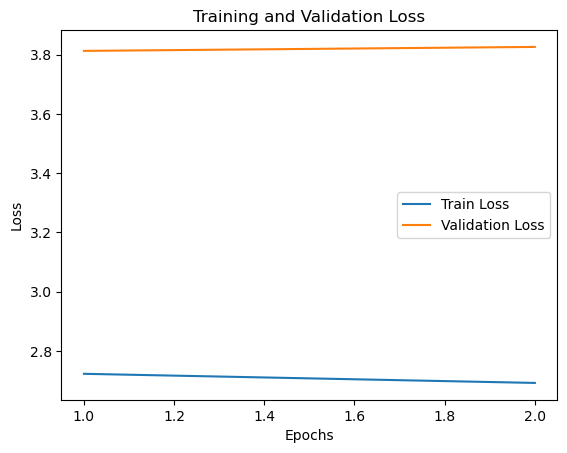

In [55]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.show()

In [58]:
print("model_v2" in globals())
print("Seq2SeqWithAttentionV2" in globals())
print("Encoder" in globals())
print("Decoder" in globals())

False
False
True
True


In [60]:
import torch
import torch.nn as nn
import torch.nn.functional as F

embedding_dim = 128
hidden_size = 256


class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell


class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

    def forward(self, x, hidden, cell):
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        return outputs, hidden, cell


class AttentionDotMasked(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, decoder_outputs, encoder_outputs, encoder_input):
        scores = torch.bmm(
            decoder_outputs,
            encoder_outputs.transpose(1, 2)
        )

        # encoder_input에서 0은 PAD 토큰이므로 attention에서 제외
        pad_mask = (encoder_input != 0).unsqueeze(1)
        scores = scores.masked_fill(~pad_mask, -1e9)

        attn_weights = F.softmax(scores, dim=-1)
        context = torch.bmm(attn_weights, encoder_outputs)

        return context, attn_weights


class Seq2SeqWithAttentionV2(nn.Module):
    def __init__(self, encoder, decoder, hidden_size, tar_vocab_size):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.attention = AttentionDotMasked()
        self.concat = nn.Linear(hidden_size * 2, hidden_size)
        self.output_layer = nn.Linear(hidden_size, tar_vocab_size)

    def forward(self, encoder_input, decoder_input):
        encoder_outputs, hidden, cell = self.encoder(encoder_input)
        decoder_outputs, _, _ = self.decoder(decoder_input, hidden, cell)

        context, attn_weights = self.attention(
            decoder_outputs,
            encoder_outputs,
            encoder_input
        )

        concat_output = torch.cat([decoder_outputs, context], dim=-1)
        concat_output = torch.tanh(self.concat(concat_output))

        outputs = self.output_layer(concat_output)
        return outputs

In [61]:
encoder_v2 = Encoder(
    len(src_vocab),
    embedding_dim,
    hidden_size,
    num_layers=2,
    dropout=0.2
)

decoder_v2 = Decoder(
    len(tar_vocab),
    embedding_dim,
    hidden_size,
    num_layers=2,
    dropout=0.2
)

model_v2 = Seq2SeqWithAttentionV2(
    encoder_v2,
    decoder_v2,
    hidden_size,
    len(tar_vocab)
)

print(model_v2)

Seq2SeqWithAttentionV2(
  (encoder): Encoder(
    (embedding): Embedding(10000, 128, padding_idx=0)
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.2)
  )
  (decoder): Decoder(
    (embedding): Embedding(5000, 128, padding_idx=0)
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.2)
  )
  (attention): AttentionDotMasked()
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=5000, bias=True)
)


In [63]:
batch_size = 256
epochs = 50
learning_rate = 0.0005
patience = 5

criterion = nn.CrossEntropyLoss(ignore_index=0)

optimizer = optim.AdamW(
    model_v2.parameters(),
    lr=learning_rate,
    weight_decay=1e-5
)

In [64]:
print("train_loader" in globals())
print("test_loader" in globals())

True
True


In [65]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    encoder_input_train,
    decoder_input_train,
    decoder_target_train
)

test_dataset = TensorDataset(
    encoder_input_test,
    decoder_input_test,
    decoder_target_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("train batch 개수:", len(train_loader))
print("test batch 개수:", len(test_loader))

train batch 개수: 308
test batch 개수: 77


In [66]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_v2.to(device)

Using device: cuda


Seq2SeqWithAttentionV2(
  (encoder): Encoder(
    (embedding): Embedding(10000, 128, padding_idx=0)
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.2)
  )
  (decoder): Decoder(
    (embedding): Embedding(5000, 128, padding_idx=0)
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.2)
  )
  (attention): AttentionDotMasked()
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=5000, bias=True)
)

In [67]:
import copy

train_losses_v2 = []
val_losses_v2 = []

def train_model_v2(model, train_loader, test_loader, criterion, optimizer, epochs, patience):
    best_val_loss = float('inf')
    early_stop_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for enc_input, dec_input, target in train_loader:
            enc_input = enc_input.to(device).long()
            dec_input = dec_input.to(device).long()
            target = target.to(device).long()

            optimizer.zero_grad()

            output = model(enc_input, dec_input)

            output = output.reshape(-1, output.shape[-1])
            target = target.reshape(-1)

            loss = criterion(output, target)
            loss.backward()

            # LSTM 학습 안정화를 위한 gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses_v2.append(avg_loss)

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for enc_input, dec_input, target in test_loader:
                enc_input = enc_input.to(device).long()
                dec_input = dec_input.to(device).long()
                target = target.to(device).long()

                output = model(enc_input, dec_input)

                output = output.reshape(-1, output.shape[-1])
                target = target.reshape(-1)

                loss = criterion(output, target)
                val_loss += loss.item()

        val_loss /= len(test_loader)
        val_losses_v2.append(val_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {avg_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
            print("  best model updated")
        else:
            early_stop_counter += 1
            print(f"  no improvement count: {early_stop_counter}/{patience}")

        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch + 1}")
            if best_model_state is not None:
                model.load_state_dict(best_model_state)
            break

    print("Training finished.")
    print("Best Val Loss:", best_val_loss)

In [68]:
train_model_v2(
    model_v2,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    epochs,
    patience
)

Epoch 1/50 | Train Loss: 6.2504 | Val Loss: 5.9845
  best model updated
Epoch 2/50 | Train Loss: 5.8888 | Val Loss: 5.7227
  best model updated
Epoch 3/50 | Train Loss: 5.6243 | Val Loss: 5.4889
  best model updated
Epoch 4/50 | Train Loss: 5.3565 | Val Loss: 5.1979
  best model updated
Epoch 5/50 | Train Loss: 5.0718 | Val Loss: 4.9719
  best model updated
Epoch 6/50 | Train Loss: 4.8454 | Val Loss: 4.7921
  best model updated
Epoch 7/50 | Train Loss: 4.6535 | Val Loss: 4.6543
  best model updated
Epoch 8/50 | Train Loss: 4.4910 | Val Loss: 4.5366
  best model updated
Epoch 9/50 | Train Loss: 4.3484 | Val Loss: 4.4371
  best model updated
Epoch 10/50 | Train Loss: 4.2188 | Val Loss: 4.3596
  best model updated
Epoch 11/50 | Train Loss: 4.0968 | Val Loss: 4.2843
  best model updated
Epoch 12/50 | Train Loss: 3.9854 | Val Loss: 4.2259
  best model updated
Epoch 13/50 | Train Loss: 3.8790 | Val Loss: 4.1664
  best model updated
Epoch 14/50 | Train Loss: 3.7784 | Val Loss: 4.1154
  best m

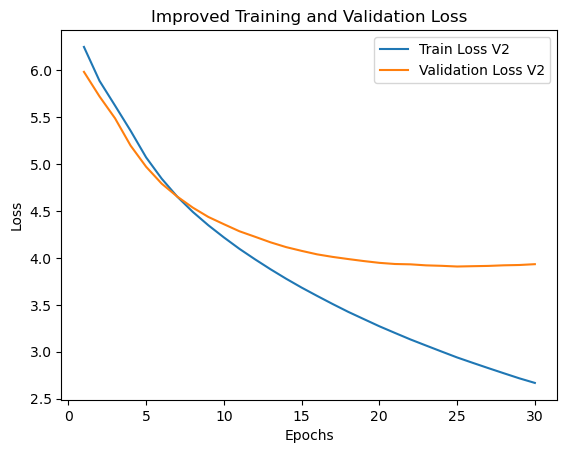

In [69]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(train_losses_v2) + 1), train_losses_v2, label='Train Loss V2')
plt.plot(range(1, len(val_losses_v2) + 1), val_losses_v2, label='Validation Loss V2')

plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Improved Training and Validation Loss")
plt.show()

모델이 학습 데이터를 따라가고 있고, 검증 데이터에서도 초반에는 성능이 개선되었지만 후반부 3.9쯤부터 주황색 Validation Loss가 어느 지점부터 거의 평평해지거나 살짝 올라가고 있어서 모델이 훈련 데이터는 계속 더 잘 맞추고 있지만, 검증 데이터 성능은 더 이상 개선되지 않는 구간에 들어갔다고 볼 수 있다. 해석 결과를 보니 후반부에 과적합이 조금 시작된 상태라고 한다.

Best Val Loss: 3.9083
개선 모델은 train loss와 validation loss가 함께 감소하는 안정적인 학습 곡선을 보였으나, 최종 best validation loss는 이전 모델보다 낮아지지는 않았다. 다만 PAD masking, gradient clipping, learning rate 조정으로 학습 과정은 더 안정적으로 진행되었다.

In [70]:
print("train_losses_v2:", train_losses_v2)
print("val_losses_v2:", val_losses_v2)

print("Best Train Loss:", min(train_losses_v2))
print("Best Val Loss:", min(val_losses_v2))
print("Best Val Epoch:", val_losses_v2.index(min(val_losses_v2)) + 1)

train_losses_v2: [6.250422072100949, 5.8887612339738125, 5.624291450946362, 5.356510300140877, 5.071810330663409, 4.845383633266795, 4.653526982703767, 4.491039918614672, 4.348370860149334, 4.218773171499178, 4.096838351193961, 3.9853777010719496, 3.8790231339343184, 3.7783806610417057, 3.683530208352324, 3.5945776344893816, 3.507978597244659, 3.4245303760875356, 3.3475578055753337, 3.2709393253574124, 3.2000825335453085, 3.130416138605638, 3.065734444500564, 3.0016720960666605, 2.9384461540680427, 2.881234184488074, 2.825119616923394, 2.77003795450384, 2.7159197516255564, 2.666822115322212]
val_losses_v2: [5.984497472837374, 5.722656683488325, 5.488929990050081, 5.197883073385659, 4.971904810372886, 4.792094354505663, 4.654264443880551, 4.536590260344666, 4.437064189415474, 4.359567722716889, 4.284303312177782, 4.225910824614686, 4.1663541236481105, 4.115364548447844, 4.075166956170813, 4.037920196335037, 4.010752021492301, 3.9878849890324974, 3.9664764497187233, 3.9474957763374627, 3

## 개선 모델 학습 결과 분석

초기 모델은 train loss가 소폭 감소했지만 validation loss가 바로 증가하여 epoch 2에서 Early Stopping이 발생하였다. 이를 개선하기 위해 learning rate를 0.001에서 0.0005로 낮추고, patience를 5로 증가시켰다. 또한 LSTM layer 수를 3층에서 2층으로 줄이고 dropout을 0.4에서 0.2로 조정하였다. Attention 계산 시 PAD 토큰을 참조하지 않도록 masking을 추가하였고, LSTM 학습 안정화를 위해 gradient clipping을 적용하였다.

개선 모델의 학습 결과 train loss는 6.2504에서 2.6668까지 지속적으로 감소하였다. validation loss도 초반에는 5.9845에서 3.9084까지 감소하여 모델이 검증 데이터에 대해서도 일정 수준 학습하고 있음을 확인할 수 있었다. 가장 낮은 validation loss는 epoch 25에서 나타났으며, Best Val Loss는 3.9084였다.

다만 epoch 25 이후에는 train loss는 계속 감소했지만 validation loss는 다시 소폭 증가하였다. 이는 모델이 훈련 데이터에 더 강하게 맞춰지면서 과적합이 시작된 것으로 해석할 수 있다. 따라서 최종 모델은 validation loss가 가장 낮았던 epoch 25의 가중치를 사용하는 것이 적절하다.

In [71]:
src_index_to_word = {idx: word for word, idx in src_vocab.items()}
tar_word_to_index = tar_vocab
tar_index_to_word = {idx: word for word, idx in tar_vocab.items()}

def seq2text(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item()) if hasattr(i, 'item') else int(i)
        if key != 0:
            temp += src_index_to_word.get(key, "<UNK>") + ' '
    return temp.strip()

def seq2summary(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item()) if hasattr(i, 'item') else int(i)

        if key == 0:
            continue
        if key == tar_word_to_index.get('sostoken'):
            continue
        if key == tar_word_to_index.get('eostoken'):
            continue

        temp += tar_index_to_word.get(key, "<UNK>") + ' '
    return temp.strip()

def clean_generated_summary(text):
    return text.replace("<UNK>", "").replace("  ", " ").strip()

In [72]:
def greedy_decode_v2(input_seq):
    model_v2.eval()

    input_seq = input_seq.to(device).long()

    with torch.no_grad():
        encoder_outputs, hidden, cell = model_v2.encoder(input_seq)

    target_seq = torch.tensor(
        [[tar_word_to_index['sostoken']]],
        dtype=torch.long,
        device=device
    )

    decoded_sentence = []

    for _ in range(summary_max_len):
        with torch.no_grad():
            decoder_outputs, hidden, cell = model_v2.decoder(target_seq, hidden, cell)

            context, _ = model_v2.attention(
                decoder_outputs,
                encoder_outputs,
                input_seq
            )

            concat_output = torch.cat([decoder_outputs, context], dim=-1)
            concat_output = torch.tanh(model_v2.concat(concat_output))

            output = model_v2.output_layer(concat_output)

            sampled_token_index = torch.argmax(output[0, -1, :]).item()
            sampled_token = tar_index_to_word.get(sampled_token_index, "<UNK>")

        if sampled_token == 'eostoken':
            break

        decoded_sentence.append(sampled_token)

        target_seq = torch.tensor(
            [[sampled_token_index]],
            dtype=torch.long,
            device=device
        )

    return ' '.join(decoded_sentence)

In [73]:
for i in range(10):
    print("원문 :", seq2text(encoder_input_test[i]))
    print("실제 요약 :", seq2summary(decoder_input_test[i]))

    input_seq = encoder_input_test[i].unsqueeze(0)
    pred = greedy_decode_v2(input_seq)

    print("개선 모델 추상적 요약 원본 :", pred)
    print("개선 모델 추상적 요약 정리본 :", clean_generated_summary(pred))

    print("-" * 80)

원문 : karan johar said directorial <UNK> dil hai <UNK> film completely satisfied one film would change anything added speaking films johar said think <UNK> <UNK> scenes kuch kuch hota hai kabhi khushi <UNK> <UNK> probably long
실제 요약 : <UNK> dil hai <UNK> my only film am <UNK> with johar
개선 모델 추상적 요약 원본 : <UNK> <UNK> <UNK> <UNK> <UNK> hai johar on johar <UNK>
개선 모델 추상적 요약 정리본 : hai johar on johar
--------------------------------------------------------------------------------
원문 : chennai woman committed suicide husband justified affair another woman saying could stop supreme court recently ruled adultery crime anymore wife earlier threatened call police came know affair ill couple married two years
실제 요약 : wife ends life after man <UNK> affair saying <UNK> is legal
개선 모델 추상적 요약 원본 : woman commits suicide after marriage family marries her marriage
개선 모델 추상적 요약 정리본 : woman commits suicide after marriage family marries her marriage
----------------------------------------------------------

In [74]:
abstractive_v2_results = []

for i in range(10):
    original = seq2text(encoder_input_test[i])
    real_summary = seq2summary(decoder_input_test[i])

    input_seq = encoder_input_test[i].unsqueeze(0)
    pred = greedy_decode_v2(input_seq)

    abstractive_v2_results.append({
        "원문": original,
        "실제 요약": real_summary,
        "개선 모델 추상적 요약 원본": pred,
        "개선 모델 추상적 요약 정리본": clean_generated_summary(pred)
    })

abstractive_v2_df = pd.DataFrame(abstractive_v2_results)
abstractive_v2_df

,원문,실제 요약,개선 모델 추상적 요약 원본,개선 모델 추상적 요약 정리본
0,karan johar said directorial <UNK> dil hai <UN...,<UNK> dil hai <UNK> my only film am <UNK> with...,<UNK> <UNK> <UNK> <UNK> <UNK> hai johar on joh...,hai johar on johar
1,chennai woman committed suicide husband justif...,wife ends life after man <UNK> affair saying <...,woman commits suicide after marriage family ma...,woman commits suicide after marriage family ma...
2,president ram nath kovind along wife son daugh...,prez kovind offers prayers at <UNK> <UNK> temple,prez kovind son daughter <UNK> to temple in te...,prez kovind son daughter to temple in temple
3,mars probably experiences fast falling <UNK> n...,<UNK> <UNK> likely hit mars during night study,mars <UNK> could be <UNK> on <UNK> <UNK>,mars could be on
4,seven members rashtriya janata dal party booke...,rjd leaders booked for forcing gangrape victim...,bjp leader booked for forcing <UNK> to prove h...,bjp leader booked for forcing to prove him to ...
5,delhi based <UNK> startup <UNK> raised crore s...,delhi startup <UNK> raises cr at cr valuation,<UNK> startup <UNK> raises crore in series fun...,startup raises crore in series funding
6,official sources wednesday said cabinet commit...,parliament winter session to be held from dec ...,<UNK> panel to ban parliament in parliament on...,panel to ban parliament in parliament on day
7,school <UNK> <UNK> mandir uttarakhand <UNK> co...,school building collapses in khand after heavy...,<UNK> <UNK> in goa to be collapses in meghalaya,in goa to be collapses in meghalaya
8,gurugram based online marketplace <UNK> laid e...,online <UNK> <UNK> fires employees,<UNK> <UNK> employees to be shut down by,employees to be shut down by
9,<UNK> sinha director rishi kapoor taapsee pann...,order of <UNK> <UNK> release not been served d...,rishi kapoor <UNK> to release on <UNK> reports,rishi kapoor to release on reports


In [2]:
!pip install --upgrade summa
!pip install --upgrade nltk
!pip install beautifulsoup4 lxml tqdm

In [4]:
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv",
    filename="news_summary_more.csv"
)
data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')

NameError: name 'urllib' is not defined

In [5]:
import urllib.request
import pandas as pd

In [6]:
import urllib.request
import pandas as pd

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv",
    filename="news_summary_more.csv"
)

data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')

print("전체 샘플 수:", len(data))
print(data.columns)
data.head()

전체 샘플 수: 98401
Index(['headlines', 'text'], dtype='object')


,headlines,text
0,upGrad learner switches to career in ML & Al w...,"Saurav Kant, an alumnus of upGrad and IIIT-B's..."
1,Delhi techie wins free food from Swiggy for on...,Kunal Shah's credit card bill payment platform...
2,New Zealand end Rohit Sharma-led India's 12-ma...,New Zealand defeated India by 8 wickets in the...
3,Aegon life iTerm insurance plan helps customer...,"With Aegon Life iTerm Insurance plan, customer..."
4,"Have known Hirani for yrs, what if MeToo claim...",Speaking about the sexual harassment allegatio...


In [7]:
print("결측값 확인")
print(data.isnull().sum())

print("\n중복 제거 전 샘플 수:", len(data))
print("text 유니크 개수:", data['text'].nunique())
print("headlines 유니크 개수:", data['headlines'].nunique())

data.drop_duplicates(subset=['text'], inplace=True)
data.dropna(axis=0, inplace=True)

print("\n중복/결측 제거 후 샘플 수:", len(data))
print(data.isnull().sum())

결측값 확인
headlines    0
text         0
dtype: int64

중복 제거 전 샘플 수: 98401
text 유니크 개수: 98360
headlines 유니크 개수: 98280

중복/결측 제거 후 샘플 수: 98360
headlines    0
text         0
dtype: int64


In [8]:
import re
import html
import numpy as np
from collections import Counter
from tqdm import tqdm

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

contractions = {
    "ain't": "is not",
    "aren't": "are not",
    "can't": "cannot",
    "couldn't": "could not",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hasn't": "has not",
    "haven't": "have not",
    "he's": "he is",
    "i'm": "i am",
    "it's": "it is",
    "let's": "let us",
    "shouldn't": "should not",
    "that's": "that is",
    "there's": "there is",
    "they're": "they are",
    "wasn't": "was not",
    "weren't": "were not",
    "what's": "what is",
    "won't": "will not",
    "wouldn't": "would not",
    "you're": "you are"
}

HTML_CLEANER = re.compile("<[^>]*>")
PAREN_CLEANER = re.compile(r"\([^)]*\)")
QUOTE_CLEANER = re.compile('"')
POSSESSIVE_CLEANER = re.compile(r"'s\b")
NON_ALPHA_CLEANER = re.compile("[^a-zA-Z]")
M_CLEANER = re.compile("[m]{2,}")

def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = str(sentence).lower()
    sentence = HTML_CLEANER.sub("", sentence)
    sentence = html.unescape(sentence)
    sentence = PAREN_CLEANER.sub("", sentence)
    sentence = QUOTE_CLEANER.sub("", sentence)

    sentence = " ".join(
        contractions[word] if word in contractions else word
        for word in sentence.split()
    )

    sentence = POSSESSIVE_CLEANER.sub("", sentence)
    sentence = NON_ALPHA_CLEANER.sub(" ", sentence)
    sentence = M_CLEANER.sub("mm", sentence)

    words = sentence.split()

    if remove_stopwords:
        result = " ".join(
            word for word in words
            if word not in stop_words and len(word) > 1
        )
    else:
        result = " ".join(
            word for word in words
            if len(word) > 1
        )

    return result

print("전처리 함수 준비 완료")

전처리 함수 준비 완료


[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [9]:
temp_text = "India's economy wasn't slowing down <br /> according to officials."
temp_headline = "India's economy wasn't slowing down"

print("text:", preprocess_sentence(temp_text, remove_stopwords=True))
print("headline:", preprocess_sentence(temp_headline, remove_stopwords=False))

text: india economy slowing according officials
headline: india economy was not slowing down


In [10]:
clean_text = [
    preprocess_sentence(sentence, remove_stopwords=True)
    for sentence in tqdm(data['text'])
]

clean_headlines = [
    preprocess_sentence(sentence, remove_stopwords=False)
    for sentence in tqdm(data['headlines'])
]

data['text'] = clean_text
data['headlines'] = clean_headlines

data.replace('', np.nan, inplace=True)
print("전처리 후 결측값:")
print(data.isnull().sum())

data.dropna(axis=0, inplace=True)

print("빈 샘플 제거 후 샘플 수:", len(data))
data.head()

100%|██████████| 98360/98360 [00:01<00:00, 57905.03it/s]


전처리 후 결측값:
headlines    0
text         0
dtype: int64
빈 샘플 제거 후 샘플 수: 98360


,headlines,text
0,upgrad learner switches to career in ml al wit...,saurav kant alumnus upgrad iiit pg program mac...
1,delhi techie wins free food from swiggy for on...,kunal shah credit card bill payment platform c...
2,new zealand end rohit sharma led india match w...,new zealand defeated india wickets fourth odi ...
3,aegon life iterm insurance plan helps customer...,aegon life iterm insurance plan customers enjo...
4,have known hirani for yrs what if metoo claims...,speaking sexual harassment allegations rajkuma...


Text 최소 길이: 1
Text 최대 길이: 60
Text 평균 길이: 35.095404636030906
Summary 최소 길이: 1
Summary 최대 길이: 16
Summary 평균 길이: 9.29690931272875


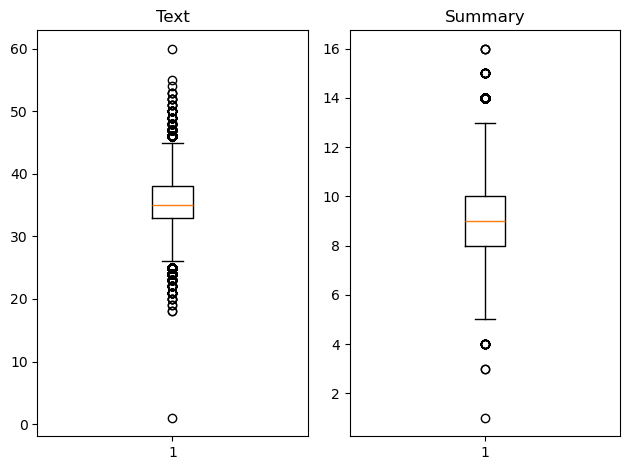

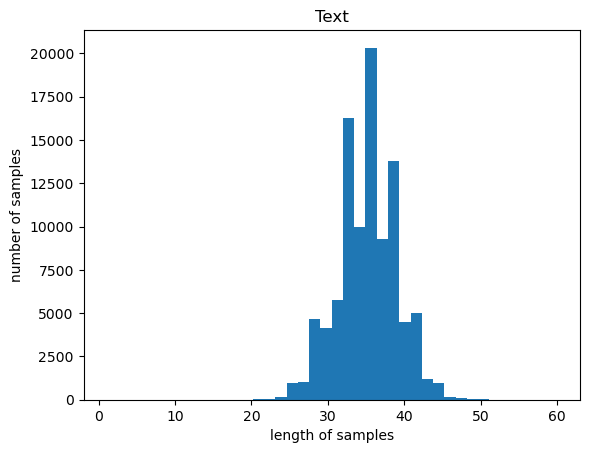

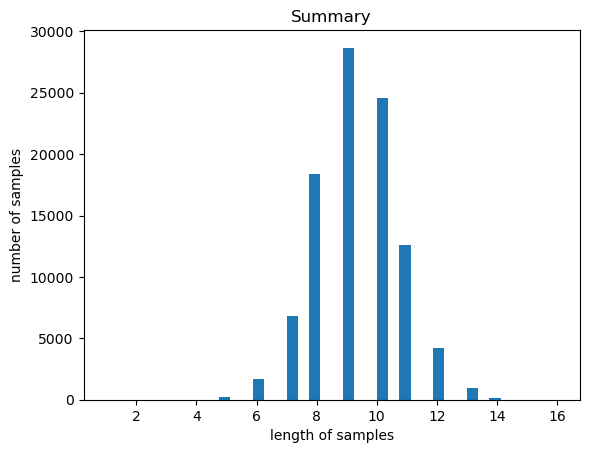

In [11]:
import numpy as np
import matplotlib.pyplot as plt

text_len = [len(s.split()) for s in data['text']]
summary_len = [len(s.split()) for s in data['headlines']]

print("Text 최소 길이:", np.min(text_len))
print("Text 최대 길이:", np.max(text_len))
print("Text 평균 길이:", np.mean(text_len))

print("Summary 최소 길이:", np.min(summary_len))
print("Summary 최대 길이:", np.max(summary_len))
print("Summary 평균 길이:", np.mean(summary_len))

plt.subplot(1, 2, 1)
plt.boxplot(text_len)
plt.title("Text")

plt.subplot(1, 2, 2)
plt.boxplot(summary_len)
plt.title("Summary")

plt.tight_layout()
plt.show()

plt.title("Text")
plt.hist(text_len, bins=40)
plt.xlabel("length of samples")
plt.ylabel("number of samples")
plt.show()

plt.title("Summary")
plt.hist(summary_len, bins=40)
plt.xlabel("length of samples")
plt.ylabel("number of samples")
plt.show()

뉴스 본문과 headline의 길이가 어느 정도인지 확인해서, 모델에 넣을 최대 길이를 정하는 단계

In [12]:
text_max_len = 60
summary_max_len = 15

print("text_max_len:", text_max_len)
print("summary_max_len:", summary_max_len)

text_max_len: 60
summary_max_len: 15


In [13]:
def below_threshold_len(max_len, data_list):
    count = 0
    for sentence in data_list:
        if len(sentence.split()) <= max_len:
            count += 1

    print(
        f"전체 샘플 중 길이가 {max_len} 이하인 샘플 비율: "
        f"{count / len(data_list) * 100:.2f}%"
    )

below_threshold_len(text_max_len, data['text'])
below_threshold_len(summary_max_len, data['headlines'])

전체 샘플 중 길이가 60 이하인 샘플 비율: 100.00%
전체 샘플 중 길이가 15 이하인 샘플 비율: 100.00%


In [14]:
data = data[
    data['text'].apply(lambda x: len(x.split()) <= text_max_len)
]

data = data[
    data['headlines'].apply(lambda x: len(x.split()) <= summary_max_len)
]

print("길이 필터링 후 샘플 수:", len(data))
data.head()

길이 필터링 후 샘플 수: 98357


,headlines,text
0,upgrad learner switches to career in ml al wit...,saurav kant alumnus upgrad iiit pg program mac...
1,delhi techie wins free food from swiggy for on...,kunal shah credit card bill payment platform c...
2,new zealand end rohit sharma led india match w...,new zealand defeated india wickets fourth odi ...
3,aegon life iterm insurance plan helps customer...,aegon life iterm insurance plan customers enjo...
4,have known hirani for yrs what if metoo claims...,speaking sexual harassment allegations rajkuma...


In [15]:
data['decoder_input'] = data['headlines'].apply(lambda x: 'sostoken ' + x)
data['decoder_target'] = data['headlines'].apply(lambda x: x + ' eostoken')

data[['headlines', 'decoder_input', 'decoder_target']].head()

,headlines,decoder_input,decoder_target
0,upgrad learner switches to career in ml al wit...,sostoken upgrad learner switches to career in ...,upgrad learner switches to career in ml al wit...
1,delhi techie wins free food from swiggy for on...,sostoken delhi techie wins free food from swig...,delhi techie wins free food from swiggy for on...
2,new zealand end rohit sharma led india match w...,sostoken new zealand end rohit sharma led indi...,new zealand end rohit sharma led india match w...
3,aegon life iterm insurance plan helps customer...,sostoken aegon life iterm insurance plan helps...,aegon life iterm insurance plan helps customer...
4,have known hirani for yrs what if metoo claims...,sostoken have known hirani for yrs what if met...,have known hirani for yrs what if metoo claims...


In [16]:
import numpy as np

encoder_input = np.array(data['text'])
decoder_input = np.array(data['decoder_input'])
decoder_target = np.array(data['decoder_target'])

indices = np.arange(encoder_input.shape[0])
np.random.shuffle(indices)

encoder_input = encoder_input[indices]
decoder_input = decoder_input[indices]
decoder_target = decoder_target[indices]

n_of_val = int(len(encoder_input) * 0.2)

encoder_input_train = encoder_input[:-n_of_val]
decoder_input_train = decoder_input[:-n_of_val]
decoder_target_train = decoder_target[:-n_of_val]

encoder_input_test = encoder_input[-n_of_val:]
decoder_input_test = decoder_input[-n_of_val:]
decoder_target_test = decoder_target[-n_of_val:]

print("훈련 데이터 개수:", len(encoder_input_train))
print("훈련 디코더 입력 개수:", len(decoder_input_train))
print("훈련 디코더 타깃 개수:", len(decoder_target_train))

print("테스트 데이터 개수:", len(encoder_input_test))
print("테스트 디코더 입력 개수:", len(decoder_input_test))
print("테스트 디코더 타깃 개수:", len(decoder_target_test))

print("\nencoder_input_train 예시:")
print(encoder_input_train[0])

print("\ndecoder_input_train 예시:")
print(decoder_input_train[0])

print("\ndecoder_target_train 예시:")
print(decoder_target_train[0])

훈련 데이터 개수: 78686
훈련 디코더 입력 개수: 78686
훈련 디코더 타깃 개수: 78686
테스트 데이터 개수: 19671
테스트 디코더 입력 개수: 19671
테스트 디코더 타깃 개수: 19671

encoder_input_train 예시:
talking effects social networks former facebook vp user growth chamath palihapitiya said think created tools ripping apart social fabric society works also said feels tremendous guilt company helped make added children allowed use social media platform

decoder_input_train 예시:
sostoken we made tools that are ripping apart society ex fb exec

decoder_target_train 예시:
we made tools that are ripping apart society ex fb exec eostoken


이 단계의 의미 정리

| 변수                     | 의미                                  |
| ---------------------- | ----------------------------------- |
| `encoder_input_train`  | 모델이 읽을 훈련용 뉴스 본문                    |
| `decoder_input_train`  | 디코더가 입력받는 훈련용 요약문, `sostoken`으로 시작  |
| `decoder_target_train` | 디코더가 맞춰야 하는 정답 요약문, `eostoken`으로 끝남 |
| `encoder_input_test`   | 검증/테스트용 뉴스 본문                       |
| `decoder_input_test`   | 검증/테스트용 디코더 입력                      |
| `decoder_target_test`  | 검증/테스트용 정답                          |


from collections import Counter

def tokenizer(text):
    return text.split()

def build_limited_vocab(texts, vocab_size):
    vocab = {"<PAD>": 0, "<UNK>": 1}
    word_counter = Counter()

    for text in texts:
        word_counter.update(tokenizer(text))

    for word, _ in word_counter.most_common(vocab_size - 2):
        vocab[word] = len(vocab)

    return vocab

print("단어장 생성 함수 준비 완료")

문장 속 단어들을 모델이 이해할 수 있는 숫자로 바꾸기 위해 단어 사전을 만드는 준비

In [19]:
src_vocab_size = 10000
tar_vocab_size = 5000

src_vocab = build_limited_vocab(encoder_input_train, src_vocab_size)

tar_vocab = build_limited_vocab(
    list(decoder_input_train) + list(decoder_target_train),
    tar_vocab_size
)

print("src_vocab 크기:", len(src_vocab))
print("tar_vocab 크기:", len(tar_vocab))

src_vocab 크기: 10000
tar_vocab 크기: 5000


| 단어장         | 의미                   |
| ----------- | -------------------- |
| `src_vocab` | 뉴스 본문 `text`용 단어장    |
| `tar_vocab` | 요약문 `headlines`용 단어장 |
| `<PAD>`     | 길이 맞추기용 0번 토큰        |
| `<UNK>`     | 단어장에 없는 단어 처리용 토큰    |

In [20]:
def text_to_sequence(texts, vocab):
    sequences = []

    for text in texts:
        sequence = [
            vocab.get(word, vocab["<UNK>"])
            for word in tokenizer(text)
        ]
        sequences.append(sequence)

    return sequences


encoder_input_train_seq = text_to_sequence(encoder_input_train, src_vocab)
encoder_input_test_seq = text_to_sequence(encoder_input_test, src_vocab)

decoder_input_train_seq = text_to_sequence(decoder_input_train, tar_vocab)
decoder_target_train_seq = text_to_sequence(decoder_target_train, tar_vocab)

decoder_input_test_seq = text_to_sequence(decoder_input_test, tar_vocab)
decoder_target_test_seq = text_to_sequence(decoder_target_test, tar_vocab)

print("encoder_input_train_seq 예시:", encoder_input_train_seq[0][:20])
print("decoder_input_train_seq 예시:", decoder_input_train_seq[0])
print("decoder_target_train_seq 예시:", decoder_target_train_seq[0])

encoder_input_train_seq 예시: [180, 3896, 152, 4206, 29, 135, 5826, 186, 865, 1, 1, 2, 407, 655, 4446, 1, 2502, 152, 7992, 1280]
decoder_input_train_seq 예시: [2, 111, 103, 1, 89, 81, 1, 1, 3264, 49, 308, 1390]
decoder_target_train_seq 예시: [111, 103, 1, 89, 81, 1, 1, 3264, 49, 308, 1390, 3]


텍스트 문장을 모델이 계산할 수 있는 숫자 시퀀스로 바꾸는 단계

In [21]:
import torch
from torch.nn.utils.rnn import pad_sequence

text_max_len = 60
summary_max_len = 15

def convert_to_tensor(sequences):
    return [torch.tensor(seq, dtype=torch.long) for seq in sequences]

def pad_sequences_pytorch(sequences, maxlen, padding_value=0):
    sequences = convert_to_tensor(sequences)

    padded = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=padding_value
    )

    if padded.size(1) < maxlen:
        pad_size = maxlen - padded.size(1)
        padded = torch.cat(
            [
                padded,
                torch.zeros((padded.size(0), pad_size), dtype=torch.long)
            ],
            dim=1
        )

    return padded[:, :maxlen]


encoder_input_train = pad_sequences_pytorch(encoder_input_train_seq, text_max_len)
encoder_input_test = pad_sequences_pytorch(encoder_input_test_seq, text_max_len)

decoder_input_train = pad_sequences_pytorch(decoder_input_train_seq, summary_max_len)
decoder_target_train = pad_sequences_pytorch(decoder_target_train_seq, summary_max_len)

decoder_input_test = pad_sequences_pytorch(decoder_input_test_seq, summary_max_len)
decoder_target_test = pad_sequences_pytorch(decoder_target_test_seq, summary_max_len)

print("encoder_input_train:", encoder_input_train.shape)
print("decoder_input_train:", decoder_input_train.shape)
print("decoder_target_train:", decoder_target_train.shape)

print("encoder_input_test:", encoder_input_test.shape)
print("decoder_input_test:", decoder_input_test.shape)
print("decoder_target_test:", decoder_target_test.shape)

encoder_input_train: torch.Size([78686, 60])
decoder_input_train: torch.Size([78686, 15])
decoder_target_train: torch.Size([78686, 15])
encoder_input_test: torch.Size([19671, 60])
decoder_input_test: torch.Size([19671, 15])
decoder_target_test: torch.Size([19671, 15])


| 데이터                    | 의미          | 상태             |
| ---------------------- | ----------- | -------------- |
| `encoder_input_train`  | 훈련용 뉴스 본문   | 78,686개, 길이 60 |
| `decoder_input_train`  | 훈련용 디코더 입력  | 78,686개, 길이 15 |
| `decoder_target_train` | 훈련용 정답 요약   | 78,686개, 길이 15 |
| `encoder_input_test`   | 테스트용 뉴스 본문  | 19,671개, 길이 60 |
| `decoder_input_test`   | 테스트용 디코더 입력 | 19,671개, 길이 15 |
| `decoder_target_test`  | 테스트용 정답 요약  | 19,671개, 길이 15 |

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

embedding_dim = 128
hidden_size = 256


class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell


class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

    def forward(self, x, hidden, cell):
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        return outputs, hidden, cell


class AttentionDotMasked(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, decoder_outputs, encoder_outputs, encoder_input):
        scores = torch.bmm(
            decoder_outputs,
            encoder_outputs.transpose(1, 2)
        )

        pad_mask = (encoder_input != 0).unsqueeze(1)
        scores = scores.masked_fill(~pad_mask, -1e9)

        attn_weights = F.softmax(scores, dim=-1)
        context = torch.bmm(attn_weights, encoder_outputs)

        return context, attn_weights


class Seq2SeqWithAttentionV2(nn.Module):
    def __init__(self, encoder, decoder, hidden_size, tar_vocab_size):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.attention = AttentionDotMasked()
        self.concat = nn.Linear(hidden_size * 2, hidden_size)
        self.output_layer = nn.Linear(hidden_size, tar_vocab_size)

    def forward(self, encoder_input, decoder_input):
        encoder_outputs, hidden, cell = self.encoder(encoder_input)
        decoder_outputs, _, _ = self.decoder(decoder_input, hidden, cell)

        context, attn_weights = self.attention(
            decoder_outputs,
            encoder_outputs,
            encoder_input
        )

        concat_output = torch.cat([decoder_outputs, context], dim=-1)
        concat_output = torch.tanh(self.concat(concat_output))

        outputs = self.output_layer(concat_output)
        return outputs

print("개선 모델 클래스 정의 완료")

개선 모델 클래스 정의 완료


In [23]:
encoder_v2 = Encoder(
    len(src_vocab),
    embedding_dim,
    hidden_size,
    num_layers=2,
    dropout=0.2
)

decoder_v2 = Decoder(
    len(tar_vocab),
    embedding_dim,
    hidden_size,
    num_layers=2,
    dropout=0.2
)

model_v2 = Seq2SeqWithAttentionV2(
    encoder_v2,
    decoder_v2,
    hidden_size,
    len(tar_vocab)
)

print(model_v2)

Seq2SeqWithAttentionV2(
  (encoder): Encoder(
    (embedding): Embedding(10000, 128, padding_idx=0)
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.2)
  )
  (decoder): Decoder(
    (embedding): Embedding(5000, 128, padding_idx=0)
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.2)
  )
  (attention): AttentionDotMasked()
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=5000, bias=True)
)


In [24]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_v2.to(device)

batch_size = 256
epochs = 50
learning_rate = 0.0005
patience = 5

criterion = nn.CrossEntropyLoss(ignore_index=0)

optimizer = optim.AdamW(
    model_v2.parameters(),
    lr=learning_rate,
    weight_decay=1e-5
)

train_dataset = TensorDataset(
    encoder_input_train,
    decoder_input_train,
    decoder_target_train
)

test_dataset = TensorDataset(
    encoder_input_test,
    decoder_input_test,
    decoder_target_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("train batch 개수:", len(train_loader))
print("test batch 개수:", len(test_loader))

Using device: cuda
train batch 개수: 308
test batch 개수: 77


In [25]:
import copy

train_losses_v2 = []
val_losses_v2 = []

def train_model_v2(model, train_loader, test_loader, criterion, optimizer, epochs, patience):
    best_val_loss = float('inf')
    early_stop_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for enc_input, dec_input, target in train_loader:
            enc_input = enc_input.to(device).long()
            dec_input = dec_input.to(device).long()
            target = target.to(device).long()

            optimizer.zero_grad()

            output = model(enc_input, dec_input)

            output = output.reshape(-1, output.shape[-1])
            target = target.reshape(-1)

            loss = criterion(output, target)
            loss.backward()

            # LSTM 학습 안정화
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses_v2.append(avg_loss)

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for enc_input, dec_input, target in test_loader:
                enc_input = enc_input.to(device).long()
                dec_input = dec_input.to(device).long()
                target = target.to(device).long()

                output = model(enc_input, dec_input)

                output = output.reshape(-1, output.shape[-1])
                target = target.reshape(-1)

                loss = criterion(output, target)
                val_loss += loss.item()

        val_loss /= len(test_loader)
        val_losses_v2.append(val_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {avg_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
            print("  best model updated")
        else:
            early_stop_counter += 1
            print(f"  no improvement count: {early_stop_counter}/{patience}")

        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch + 1}")
            if best_model_state is not None:
                model.load_state_dict(best_model_state)
            break

    print("Training finished.")
    print("Best Val Loss:", best_val_loss)

In [26]:
train_model_v2(
    model_v2,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    epochs,
    patience
)

Epoch 1/50 | Train Loss: 6.2621 | Val Loss: 5.9880
  best model updated
Epoch 2/50 | Train Loss: 5.8981 | Val Loss: 5.7324
  best model updated
Epoch 3/50 | Train Loss: 5.6222 | Val Loss: 5.4595
  best model updated
Epoch 4/50 | Train Loss: 5.3185 | Val Loss: 5.1671
  best model updated
Epoch 5/50 | Train Loss: 5.0284 | Val Loss: 4.9352
  best model updated
Epoch 6/50 | Train Loss: 4.7971 | Val Loss: 4.7560
  best model updated
Epoch 7/50 | Train Loss: 4.6146 | Val Loss: 4.6285
  best model updated
Epoch 8/50 | Train Loss: 4.4585 | Val Loss: 4.5134
  best model updated
Epoch 9/50 | Train Loss: 4.3175 | Val Loss: 4.4217
  best model updated
Epoch 10/50 | Train Loss: 4.1886 | Val Loss: 4.3442
  best model updated
Epoch 11/50 | Train Loss: 4.0679 | Val Loss: 4.2637
  best model updated
Epoch 12/50 | Train Loss: 3.9545 | Val Loss: 4.2008
  best model updated
Epoch 13/50 | Train Loss: 3.8475 | Val Loss: 4.1466
  best model updated
Epoch 14/50 | Train Loss: 3.7477 | Val Loss: 4.0978
  best m

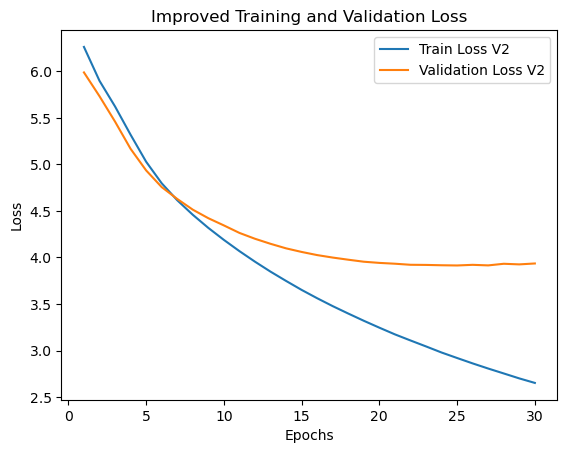

In [27]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(train_losses_v2) + 1), train_losses_v2, label='Train Loss V2')
plt.plot(range(1, len(val_losses_v2) + 1), val_losses_v2, label='Validation Loss V2')

plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Improved Training and Validation Loss")
plt.show()

In [28]:
print("Best Train Loss:", min(train_losses_v2))
print("Best Val Loss:", min(val_losses_v2))
print("Best Val Epoch:", val_losses_v2.index(min(val_losses_v2)) + 1)

Best Train Loss: 2.651950611696615
Best Val Loss: 3.913879069415006
Best Val Epoch: 25


In [29]:
src_index_to_word = {idx: word for word, idx in src_vocab.items()}
tar_word_to_index = tar_vocab
tar_index_to_word = {idx: word for word, idx in tar_vocab.items()}

def seq2text(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item()) if hasattr(i, 'item') else int(i)
        if key != 0:
            temp += src_index_to_word.get(key, "<UNK>") + ' '
    return temp.strip()

def seq2summary(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item()) if hasattr(i, 'item') else int(i)

        if key == 0:
            continue
        if key == tar_word_to_index.get('sostoken'):
            continue
        if key == tar_word_to_index.get('eostoken'):
            continue

        temp += tar_index_to_word.get(key, "<UNK>") + ' '
    return temp.strip()

def clean_generated_summary(text):
    return text.replace("<UNK>", "").replace("  ", " ").strip()

print("복원 함수 준비 완료")

복원 함수 준비 완료


In [30]:
def greedy_decode_v2(input_seq):
    model_v2.eval()

    input_seq = input_seq.to(device).long()

    with torch.no_grad():
        encoder_outputs, hidden, cell = model_v2.encoder(input_seq)

    target_seq = torch.tensor(
        [[tar_word_to_index['sostoken']]],
        dtype=torch.long,
        device=device
    )

    decoded_sentence = []

    for _ in range(summary_max_len):
        with torch.no_grad():
            decoder_outputs, hidden, cell = model_v2.decoder(target_seq, hidden, cell)

            context, _ = model_v2.attention(
                decoder_outputs,
                encoder_outputs,
                input_seq
            )

            concat_output = torch.cat([decoder_outputs, context], dim=-1)
            concat_output = torch.tanh(model_v2.concat(concat_output))

            output = model_v2.output_layer(concat_output)

            sampled_token_index = torch.argmax(output[0, -1, :]).item()
            sampled_token = tar_index_to_word.get(sampled_token_index, "<UNK>")

        if sampled_token == 'eostoken':
            break

        decoded_sentence.append(sampled_token)

        target_seq = torch.tensor(
            [[sampled_token_index]],
            dtype=torch.long,
            device=device
        )

    return ' '.join(decoded_sentence)

print("greedy_decode_v2 준비 완료")

greedy_decode_v2 준비 완료


In [31]:
for i in range(10):
    print("원문 :", seq2text(encoder_input_test[i]))
    print("실제 요약 :", seq2summary(decoder_input_test[i]))

    input_seq = encoder_input_test[i].unsqueeze(0)
    pred = greedy_decode_v2(input_seq)

    print("개선 모델 추상적 요약 원본 :", pred)
    print("개선 모델 추상적 요약 정리본 :", clean_generated_summary(pred))

    print("-" * 80)

원문 : senior advocate former law minister ram <UNK> announced retirement legal practice saturday <UNK> profession years addressing bar council india year old slammed old new governments saying would take role <UNK> corrupt politicians added nda government let nation
실제 요약 : ram <UNK> retires at after yrs of legal practice
개선 모델 추상적 요약 원본 : ex <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> law
개선 모델 추상적 요약 정리본 : ex    law
--------------------------------------------------------------------------------
원문 : talking killing saudi arabian journalist jamal khashoggi softbank ceo masayoshi son said terrible tragedy occurred adding pressed saudi government regarding matter son also said asked heart get bottom incident explain sense responsibility
실제 요약 : tragedy that should not have <UNK> son on saudi journo killing
개선 모델 추상적 요약 원본 : <UNK> is not <UNK> <UNK> on saudi arabia
개선 모델 추상적 요약 정리본 : is not  on saudi arabia
--------------------------------------------------------------------------------
원문

## 개선 모델 학습 결과 분석

초기 모델에서는 train loss가 소폭 감소했지만 validation loss가 빠르게 증가하여 조기 종료되었다. 이를 개선하기 위해 LSTM layer 수를 3층에서 2층으로 줄이고, dropout을 0.4에서 0.2로 조정하였다. 또한 learning rate를 0.001에서 0.0005로 낮추고, patience를 5로 증가시켰다. Attention 계산 시 PAD 토큰을 참조하지 않도록 masking을 추가하였으며, LSTM 학습 안정화를 위해 gradient clipping을 적용하였다.

개선 모델 학습 결과 train loss는 지속적으로 감소하였고, validation loss도 epoch 25까지 감소하는 경향을 보였다. 가장 낮은 validation loss는 epoch 25에서 기록되었으며, Best Val Loss는 약 3.9139였다. 이후 epoch 26부터는 train loss는 계속 감소했지만 validation loss는 개선되지 않았고, 5회 연속 개선이 없어 epoch 30에서 Early Stopping이 작동하였다.

따라서 최종 모델은 validation loss가 가장 낮았던 epoch 25의 가중치를 사용하는 것이 적절하다고 판단하였다. 이번 개선 실험을 통해 PAD masking, gradient clipping, learning rate 조정이 학습 안정성 향상에 도움을 줄 수 있음을 확인하였다.

## 최종 결과 요약

이번 프로젝트에서는 뉴스 기사 본문을 입력으로 받아 짧은 headline 형태의 요약문을 생성하는 텍스트 요약 실습을 수행하였다. 데이터는 `news_summary_more.csv`를 사용하였으며, 뉴스 본문에 해당하는 `text`와 정답 요약문에 해당하는 `headlines` 컬럼을 활용하였다.

전처리 과정에서는 중복값과 결측값을 제거하고, 소문자화, HTML 태그 제거, 특수문자 제거, 축약어 정규화, 불용어 제거 등을 수행하였다. 본문 `text`에는 불용어 제거를 적용하였고, 요약문 `headlines`는 자연스러운 문장 생성을 위해 불용어를 제거하지 않았다.

이후 요약문에 `sostoken`과 `eostoken`을 추가하여 seq2seq 학습 구조를 만들었다. 본문 단어장은 10,000개, 요약문 단어장은 5,000개로 제한하였고, 본문은 길이 60, 요약문은 길이 15로 패딩하였다.

최종 모델은 LSTM 기반 Encoder-Decoder 구조에 Attention을 결합한 `Seq2SeqWithAttentionV2` 모델이다. 개선 모델에서는 PAD masking Attention을 적용하여 패딩 토큰이 Attention 계산에 영향을 주지 않도록 하였고, gradient clipping과 AdamW optimizer를 사용하여 학습 안정성을 높였다.

학습 결과 train loss는 지속적으로 감소하였고, validation loss는 epoch 25까지 감소하였다. 가장 낮은 validation loss는 epoch 25에서 기록되었으며, Best Val Loss는 약 3.9139였다. 이후 validation loss가 5회 연속 개선되지 않아 epoch 30에서 Early Stopping이 작동하였다.

추상적 요약 결과에서는 일부 핵심 단어가 반영되었지만, `<UNK>` 토큰과 문법적으로 부자연스러운 표현도 남아 있었다. 반면 Summa를 활용한 추출적 요약은 원문 문장을 그대로 선택하기 때문에 문법적으로 안정적이었지만, headline처럼 짧고 압축적인 새 문장을 생성하는 데는 한계가 있었다.

종합하면, 추출적 요약은 안정적인 핵심 문장 선택에 강점이 있었고, 추상적 요약은 새로운 요약문 생성 가능성을 보여주었지만 더 많은 개선이 필요했다. 향후에는 vocabulary 크기 조정, beam search 적용, pre-trained embedding 사용, Transformer 기반 모델 적용 등을 통해 요약 품질을 개선할 수 있을 것이다.
